# Portfolio Optimization — Train & Backtest

Train PPO on `PortfolioEnvWithBaselines` (reward = Sharpe ratio),
then backtest on held-out data and compare against equal-weight,
min-variance, and buy-and-hold baselines.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath('.'))

from src.data_loader import process_data_with_indicators, split_data
from envs.portfolio_env import PortfolioEnvWithBaselines
from agent.ppo import PPO

%load_ext autoreload
%autoreload 2

## 1. Load & Process Data

In [2]:
tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA',
    'META', 'TSLA', 'NFLX', 'UNH', 'JNJ',
    'V', 'JPM', 'WMT', 'MA', 'PG',
    'HD', 'DIS', 'BAC', 'XOM', 'CVX'
]

stock_data = {}
for ticker in tickers:
    df = pd.read_csv(f'data/{ticker}.csv', skiprows=2, index_col='Date', parse_dates=True)
    df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
    stock_data[ticker] = df

stock_data = process_data_with_indicators(stock_data)
training_data, validation_data, test_data = split_data(stock_data)

print(f"Tickers:    {len(tickers)}")
print(f"Train days: {len(next(iter(training_data.values())))}")
print(f"Test days:  {len(next(iter(test_data.values())))}")

Tickers:    20
Train days: 1491
Test days:  1005


## 2. Train PPO on Portfolio Env

In [3]:
train_env = PortfolioEnvWithBaselines(training_data)

print(f"Observation dim: {train_env.observation_space.shape}")
print(f"Action dim:      {train_env.action_space.shape}")
print(f"Max steps:       {train_env.max_steps}")
print(f"Assets:          {train_env.n_assets}  (+ cash = {train_env.n_total})")

Observation dim: (493,)
Action dim:      (21,)
Max steps:       1490
Assets:          20  (+ cash = 21)


In [10]:
ppo = PPO(
    env=train_env,
    lr=3e-4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=10,
    batch_size=64,
    ent_coef=0.01,
    vf_coef=0.5,
)

N_ITERATIONS = 200
STEPS_PER_ITER = 2048

training_stats = ppo.train(n_iterations=N_ITERATIONS, steps_per_iter=STEPS_PER_ITER)

Iteration 10/200 | Mean Reward: 0.09 | Policy Loss: -0.0123 | Value Loss: 0.0388 | Entropy: 31.2028
Iteration 20/200 | Mean Reward: 0.09 | Policy Loss: -0.0173 | Value Loss: 0.0212 | Entropy: 32.1963
Iteration 30/200 | Mean Reward: 0.10 | Policy Loss: -0.0218 | Value Loss: 0.0169 | Entropy: 32.7572
Iteration 40/200 | Mean Reward: 0.09 | Policy Loss: -0.0206 | Value Loss: 0.0288 | Entropy: 33.4320
Iteration 50/200 | Mean Reward: 0.09 | Policy Loss: -0.0233 | Value Loss: 0.0123 | Entropy: 34.1751
Iteration 60/200 | Mean Reward: 0.09 | Policy Loss: -0.0239 | Value Loss: 0.0150 | Entropy: 35.2400
Iteration 70/200 | Mean Reward: 0.09 | Policy Loss: -0.0254 | Value Loss: 0.0079 | Entropy: 36.1149
Iteration 80/200 | Mean Reward: 0.10 | Policy Loss: -0.0268 | Value Loss: 0.0166 | Entropy: 37.2054
Iteration 90/200 | Mean Reward: 0.10 | Policy Loss: -0.0266 | Value Loss: 0.0228 | Entropy: 37.8569
Iteration 100/200 | Mean Reward: 0.09 | Policy Loss: -0.0304 | Value Loss: 0.0066 | Entropy: 38.6236

## 3. Learning Curves

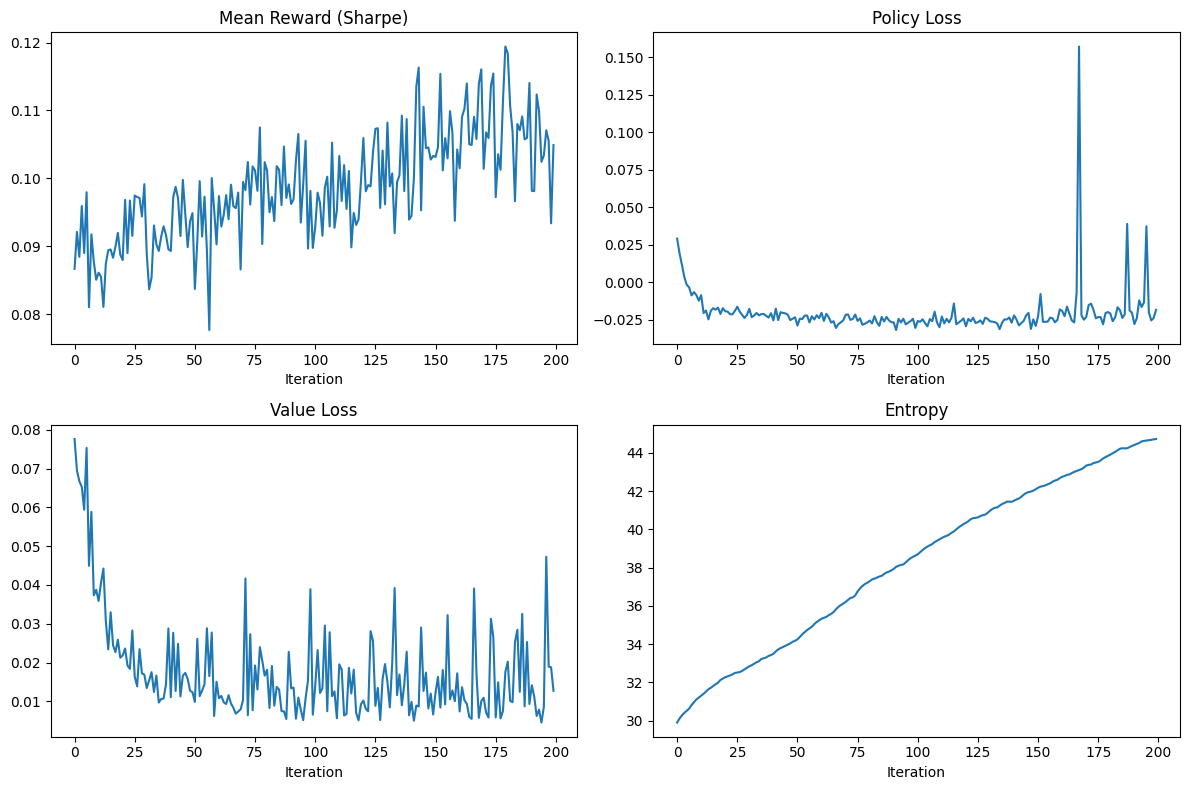

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(training_stats['mean_rewards'])
axes[0, 0].set_title('Mean Reward (Sharpe)')
axes[0, 0].set_xlabel('Iteration')

axes[0, 1].plot(training_stats['policy_losses'])
axes[0, 1].set_title('Policy Loss')
axes[0, 1].set_xlabel('Iteration')

axes[1, 0].plot(training_stats['value_losses'])
axes[1, 0].set_title('Value Loss')
axes[1, 0].set_xlabel('Iteration')

axes[1, 1].plot(training_stats['entropies'])
axes[1, 1].set_title('Entropy')
axes[1, 1].set_xlabel('Iteration')

plt.tight_layout()
plt.show()

## 4. Backtest on Test Data

In [12]:
test_env = PortfolioEnvWithBaselines(test_data)
obs, info = test_env.reset()

rl_values = [test_env.value]
baseline_values = {name: [test_env.initial_value] for name in test_env.baselines}

done = False
while not done:
    action = ppo.predict(obs)
    obs, reward, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated

    rl_values.append(info['portfolio_value'])
    for name in test_env.baselines:
        baseline_values[name].append(info.get(f'baseline_{name}', baseline_values[name][-1]))

print(f"Backtest finished — {len(rl_values)} steps")

Backtest finished — 1005 steps


## 5. Results

In [13]:
comparison = test_env.get_comparison()

print(f"{'Strategy':<16} {'Value':>12} {'Return':>10} {'Sharpe':>8}")
print('-' * 48)
for name, m in comparison.items():
    print(f"{name:<16} ${m['value']:>10,.2f} {m['return']:>+9.2f}% {m['sharpe']:>7.3f}")

Strategy                Value     Return   Sharpe
------------------------------------------------
RL Agent         $185,105.29    +85.11%   1.108
equal_weight     $211,818.36   +111.82%   1.136
min_variance     $184,621.36    +84.62%   1.205
buy_hold         $211,818.36   +111.82%   1.136


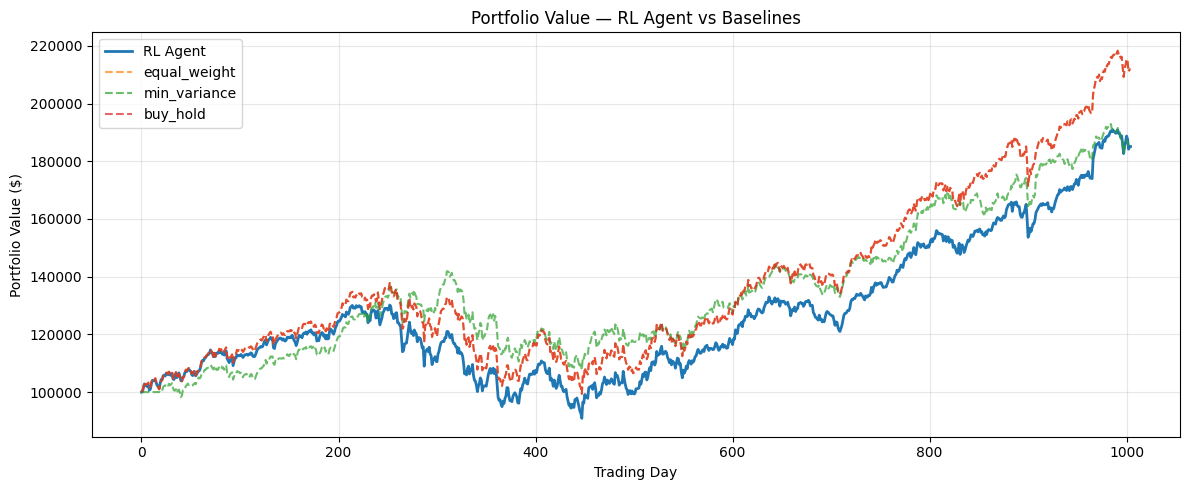

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(rl_values, label='RL Agent', linewidth=2)
for name, vals in baseline_values.items():
    plt.plot(vals, label=name, linestyle='--', alpha=0.7)
plt.title('Portfolio Value — RL Agent vs Baselines')
plt.xlabel('Trading Day')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
metrics = test_env.get_metrics()
print(f"\nRL Agent Metrics")
print(f"  Total Return:  {metrics['total_return']:+.2f}%")
print(f"  Sharpe Ratio:  {metrics['sharpe_ratio']:.3f}")
print(f"  Max Drawdown:  {metrics['max_drawdown']:.2f}%")
print(f"  Final Value:   ${metrics['final_value']:,.2f}")


RL Agent Metrics
  Total Return:  +85.11%
  Sharpe Ratio:  1.108
  Max Drawdown:  30.17%
  Final Value:   $185,105.29


## 6. Save Model

In [16]:
os.makedirs('models', exist_ok=True)
save_path = 'models/ppo_portfolio.pt'

torch.save({
    'obs_shape': train_env.observation_space.shape[0],
    'action_shape': train_env.action_space.shape[0],
    'policy_state_dict': ppo.policy.state_dict(),
}, save_path)

print(f"Model saved to {save_path}")

Model saved to models/ppo_portfolio.pt
